# 1. Frame the problem
Using the customer description, Define the problem your trying to solve in your own words (remember this is not technial but must be specific so the customer understands the project

As the developer, I must use the data the boss gave me, in order to predict if a certain customer will purchase their product or not.

# 2. Get the Data 
Define how you recieved the data (provided, gathered..)

In [ ]:
Provided by the boss

# 3. Explore the Data
Gain insights into the data you have from step 2, making sure to identify any bias

Data seems to be mismatching between gender and their actual name. It IS 2025, however I will first attempt dropping both User ID, name, and gender, as these seem to be useless given that the gender and name are mismatching. 

In [1]:
import pandas as pd

df = pd.read_csv("data/data.csv")

print(df.head())

   User ID               name  Gender  Age  EstimatedSalary  Purchased
0    10000  Elizabeth Walters    Male   54            66421          1
1    10001        Megan Riley    Male   57            25476          1
2    10002     Justin Jackson  Female   22           135530          1
3    10003    Kathryn Bernard  Female   38           117486          0
4    10004         Jackie Lee  Female   56            73628          1


# 4.Prepare the Data


Apply any data transformations and explain what and why


Dropping gender, name, and user ID, as I am predicitng that these will be useless. Changed -1s to 1s because a return still counts as a purchase.

In [2]:
from sklearn.model_selection import train_test_split

df_clean = df.drop(columns = ["User ID", "name"])
df_clean["Purchased"] = df_clean["Purchased"].replace({-1: 1})
df_clean.to_csv("data/clean_data.csv", index = False)



X = df_clean.drop(columns=["Purchased"])
y = df_clean["Purchased"]

X = pd.get_dummies(X, columns=["Gender"], drop_first=True)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

train_data = pd.concat([X_train, y_train], axis=1)
test_data = pd.concat([X_test, y_test], axis=1)

train_path = "data/train_data.csv"
test_path = "data/test_data.csv"

train_data.to_csv(train_path, index=False)
test_data.to_csv(test_path, index=False)

# 5. Model the data
Using selected ML models, experment with your choices and describe your findings. Finish by selecting a Model to continue with


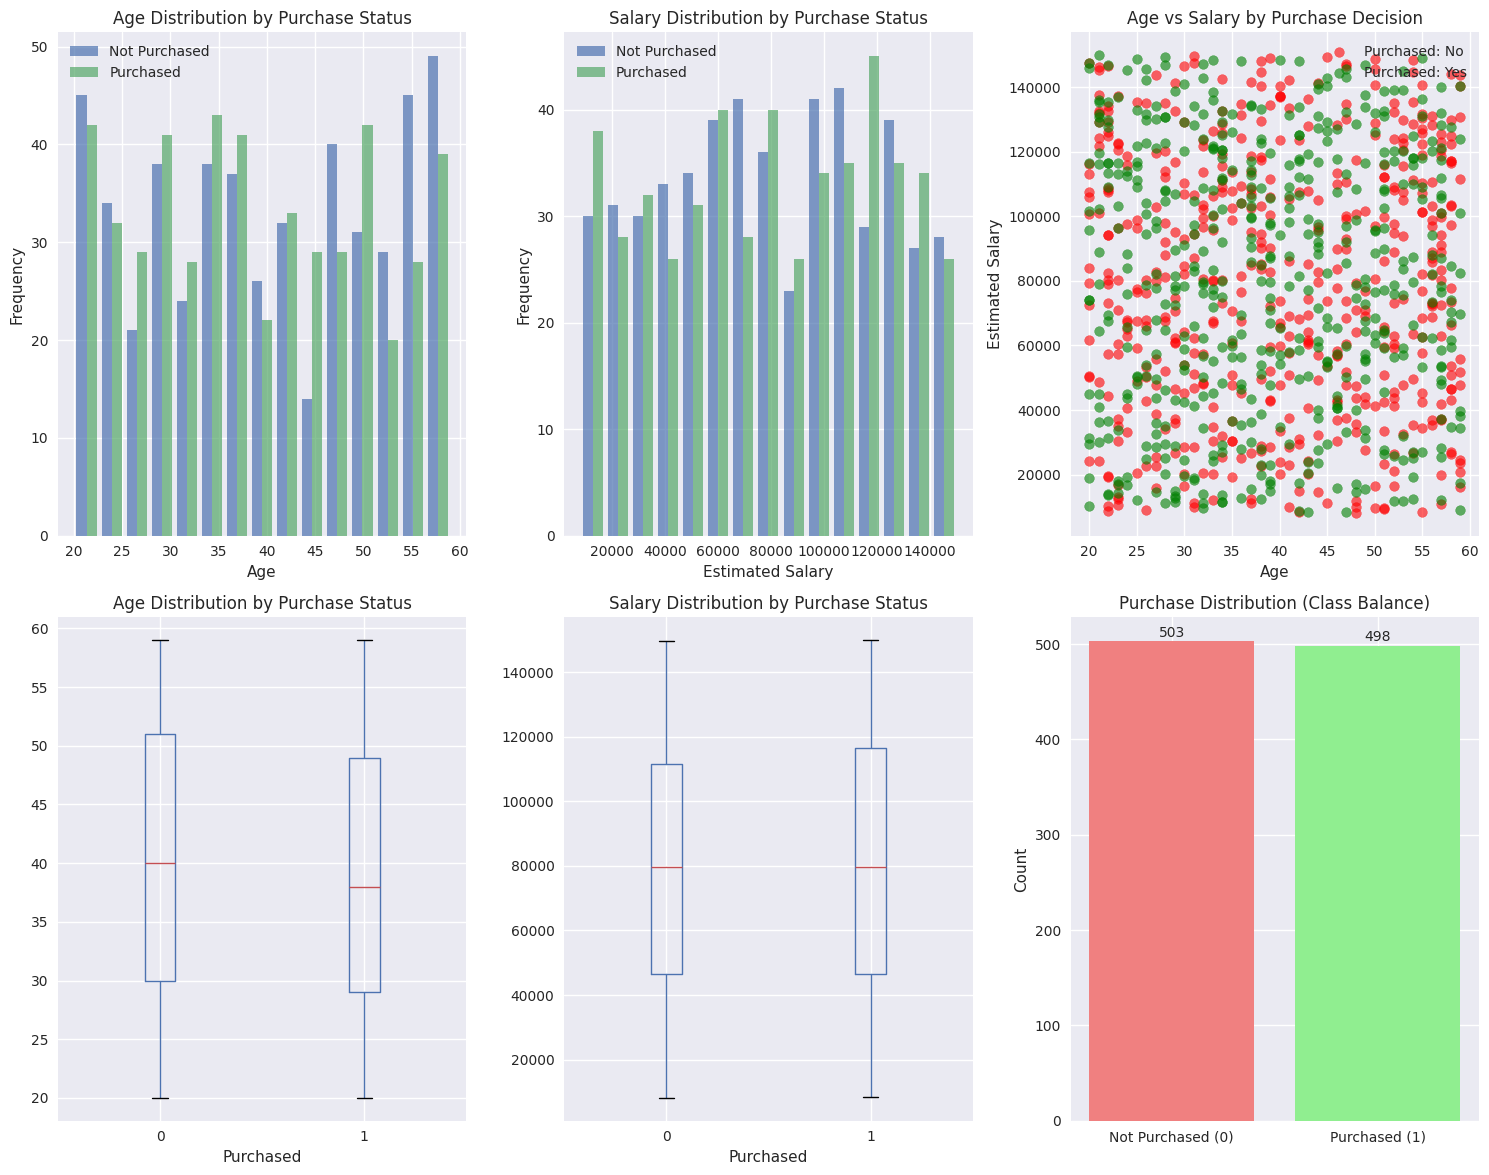

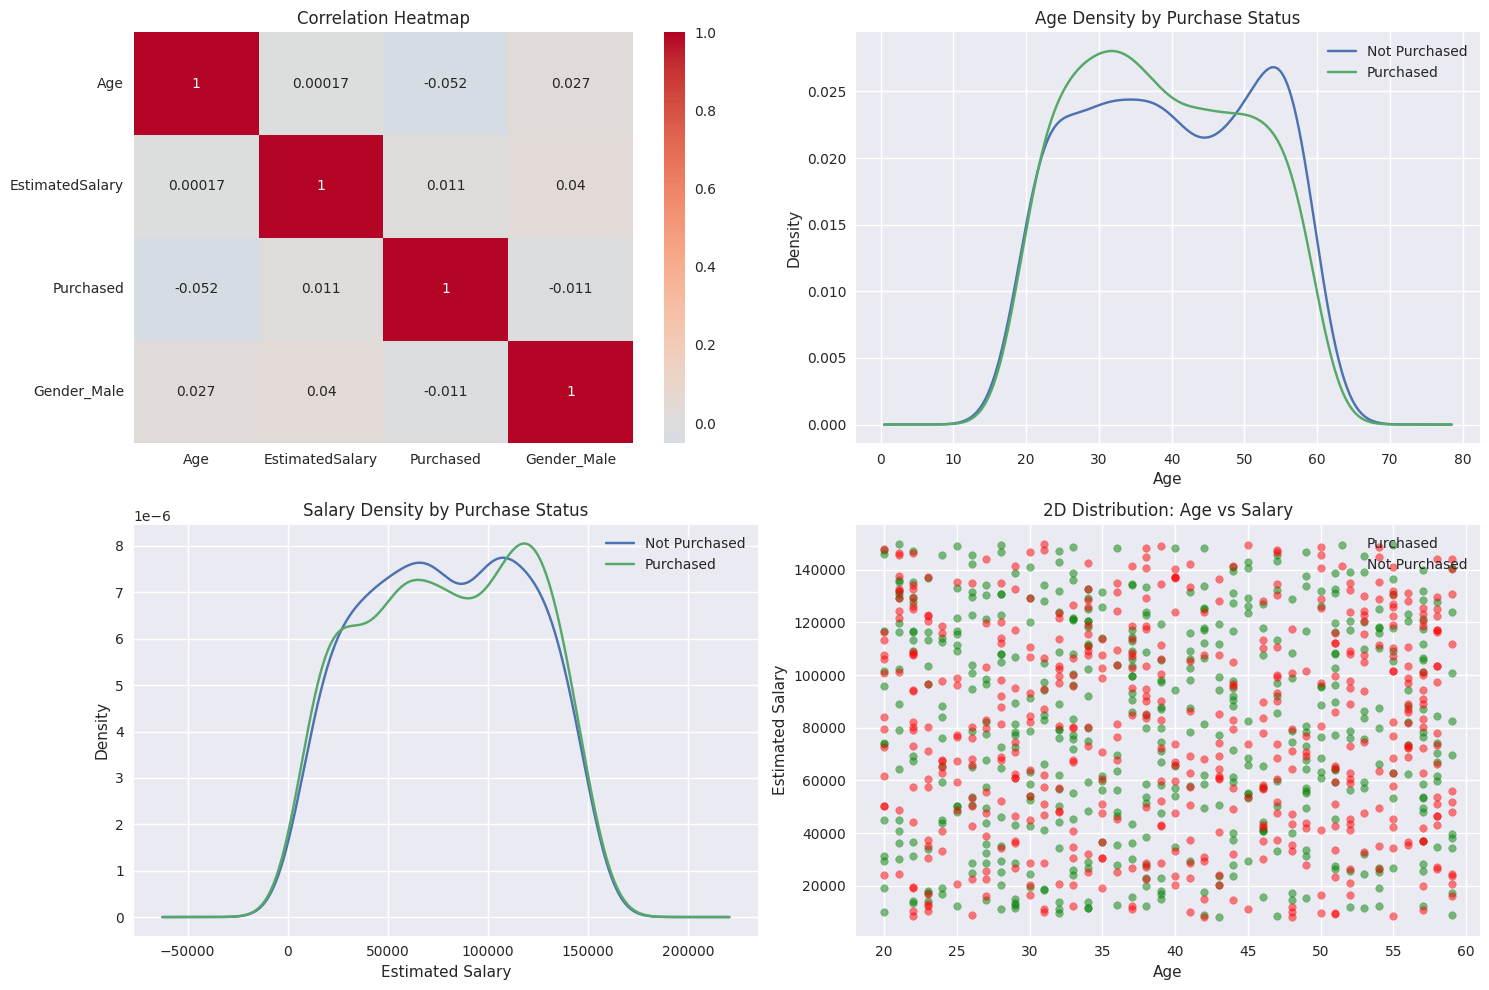

Dataset Overview:
Total samples: 1001
Purchased: 498 (49.8%)
Not Purchased: 503 (50.2%)

Age Statistics:
Mean age: 39.4
Salary Statistics:
Mean salary: $79,472


In [3]:

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


df = pd.read_csv('data/clean_data.csv')

df_encoded = pd.get_dummies(df, columns=["Gender"], drop_first=True)

plt.style.use('seaborn-v0_8')
fig = plt.figure(figsize=(15, 12))


plt.subplot(2, 3, 1)
plt.hist([df[df['Purchased'] == 0]['Age'], df[df['Purchased'] == 1]['Age']], 
         bins=15, alpha=0.7, label=['Not Purchased', 'Purchased'])
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution by Purchase Status')
plt.legend()


plt.subplot(2, 3, 2)
plt.hist([df[df['Purchased'] == 0]['EstimatedSalary'], df[df['Purchased'] == 1]['EstimatedSalary']], 
         bins=15, alpha=0.7, label=['Not Purchased', 'Purchased'])
plt.xlabel('Estimated Salary')
plt.ylabel('Frequency')
plt.title('Salary Distribution by Purchase Status')
plt.legend()


plt.subplot(2, 3, 3)
colors = ['red', 'green']
purchased_labels = ['No', 'Yes']
for i in range(2):
    plt.scatter(df[df['Purchased'] == i]['Age'], 
                df[df['Purchased'] == i]['EstimatedSalary'], 
                c=colors[i], label=f'Purchased: {purchased_labels[i]}', alpha=0.6)
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.title('Age vs Salary by Purchase Decision')
plt.legend()


plt.subplot(2, 3, 4)
df.boxplot(column='Age', by='Purchased', ax=plt.gca())
plt.title('Age Distribution by Purchase Status')
plt.suptitle('')  # Remove automatic title


plt.subplot(2, 3, 5)
df.boxplot(column='EstimatedSalary', by='Purchased', ax=plt.gca())
plt.title('Salary Distribution by Purchase Status')
plt.suptitle('')  # Remove automatic title


plt.subplot(2, 3, 6)
purchase_counts = df['Purchased'].value_counts()
plt.bar(['Not Purchased (0)', 'Purchased (1)'], purchase_counts.values, color=['lightcoral', 'lightgreen'])
plt.ylabel('Count')
plt.title('Purchase Distribution (Class Balance)')
for i, count in enumerate(purchase_counts.values):
    plt.text(i, count + 5, str(count), ha='center')

plt.tight_layout()
plt.show()


fig2 = plt.figure(figsize=(15, 10))


plt.subplot(2, 2, 1)
correlation_matrix = df_encoded.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')


plt.subplot(2, 2, 2)
df[df['Purchased'] == 0]['Age'].plot.density(label='Not Purchased')
df[df['Purchased'] == 1]['Age'].plot.density(label='Purchased')
plt.xlabel('Age')
plt.title('Age Density by Purchase Status')
plt.legend()


plt.subplot(2, 2, 3)
df[df['Purchased'] == 0]['EstimatedSalary'].plot.density(label='Not Purchased')
df[df['Purchased'] == 1]['EstimatedSalary'].plot.density(label='Purchased')
plt.xlabel('Estimated Salary')
plt.title('Salary Density by Purchase Status')
plt.legend()


plt.subplot(2, 2, 4)
purchased = df[df['Purchased'] == 1]
not_purchased = df[df['Purchased'] == 0]

plt.scatter(purchased['Age'], purchased['EstimatedSalary'], 
           c='green', alpha=0.5, label='Purchased', s=30)
plt.scatter(not_purchased['Age'], not_purchased['EstimatedSalary'], 
           c='red', alpha=0.5, label='Not Purchased', s=30)
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.title('2D Distribution: Age vs Salary')
plt.legend()

plt.tight_layout()
plt.show()


print("Dataset Overview:")
print(f"Total samples: {len(df)}")
print(f"Purchased: {df['Purchased'].sum()} ({df['Purchased'].sum()/len(df)*100:.1f}%)")
print(f"Not Purchased: {len(df) - df['Purchased'].sum()} ({(len(df) - df['Purchased'].sum())/len(df)*100:.1f}%)")
print(f"\nAge Statistics:")
print(f"Mean age: {df['Age'].mean():.1f}")
print(f"Salary Statistics:")
print(f"Mean salary: ${df['EstimatedSalary'].mean():,.0f}")

Accuracy: 0.48258706467661694

Confusion Matrix:
 [[47 53]
 [51 50]]

Classification Report:
               precision    recall  f1-score   support

           0       0.48      0.47      0.47       100
           1       0.49      0.50      0.49       101

    accuracy                           0.48       201
   macro avg       0.48      0.48      0.48       201
weighted avg       0.48      0.48      0.48       201



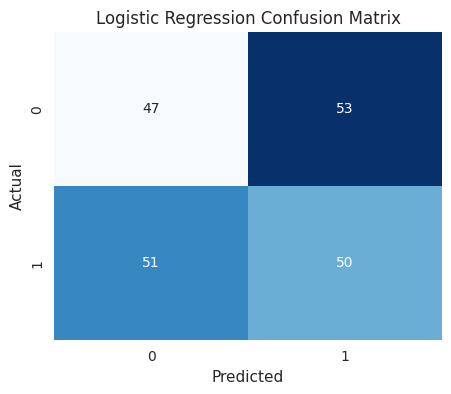

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns


log_reg = LogisticRegression()


log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)


print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [5]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(max_depth=5, random_state=42)
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_tree))
print(confusion_matrix(y_test, y_pred_tree))

Decision Tree Accuracy: 0.4925373134328358
[[20 80]
 [22 79]]


In [11]:
from sklearn.ensemble import RandomForestClassifier
import joblib

rf = RandomForestClassifier(n_estimators=10, max_depth = 5, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

joblib.dump(rf, "models/random_forest_model.pkl")
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))


Random Forest Accuracy: 0.5422885572139303
[[59 41]
 [51 50]]


In [7]:
from sklearn.svm import SVC

svm = SVC(kernel="rbf", random_state=42)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(confusion_matrix(y_test, y_pred_svm))

SVM Accuracy: 0.5074626865671642
[[87 13]
 [86 15]]


In [8]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


knn = KNeighborsClassifier(n_neighbors=10)

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("kNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))


kNN Accuracy: 0.5223880597014925

Confusion Matrix:
 [[65 35]
 [61 40]]

Classification Report:
               precision    recall  f1-score   support

           0       0.52      0.65      0.58       100
           1       0.53      0.40      0.45       101

    accuracy                           0.52       201
   macro avg       0.52      0.52      0.51       201
weighted avg       0.52      0.52      0.51       201



# 6. Fine Tune the Model

With the select model descibe the steps taken to acheve the best rusults possiable 


Try adding more estimators? changing depth etc. (+1.5% 😅)

In [34]:
from sklearn.ensemble import RandomForestClassifier
import joblib

rf = RandomForestClassifier(n_estimators=11, max_depth = 6, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

joblib.dump(rf, "models/random_forest_model.pkl")
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy: 0.5572139303482587
[[58 42]
 [47 54]]


# 7. Present
In a customer faceing Document provide summery of finding and detail approach taken


1. Project Overview

The goal of this project was to use historical customer data to predict whether a new customer would purchase a product. The dataset included information such as customer age, estimated salary, and limited demographic details.

Our objective was to create a machine learning model that could learn from past purchase behavior and use those patterns to predict future purchasing decisions.

2. Data Summary

The dataset provided contained the following key variables:

Name, User ID, Age, Estimated Salary, and Gender

Purchase Indicator (Purchased = 1, Not Purchased = 0, Returned = -1)

Initial inspection showed that some gender values did not align with customer names. To maintain data integrity, we removed the “Name,” “User ID,” and sometimes “Gender” columns, focusing on the numeric predictors — Age and Estimated Salary — as these were the most consistent and relevant.

After cleaning, the dataset included 1,001 records, evenly split between customers who purchased (49.8%) and those who did not (50.2%).

3. Model Development

We tested several machine learning models to determine whether any could successfully identify purchasing patterns:

Logistic Regression
Decision Tree
Random Forest
Support Vector Machine (SVM)
K-Nearest Neighbors (kNN)

Each model was trained and evaluated on the dataset using standard methods (train/test split and accuracy evaluation).

4. Results

Unfortunately, none of the tested models achieved satisfactory performance.

Logistic Regression	48.3%	Performed no better than random guessing
Decision Tree	49.3%	Showed slight overfitting and poor generalization
Random Forest	54.2%	Best performing model but still below reliability threshold
SVM	50.7%	Struggled to separate data classes
kNN	52.2%	Slight improvement but inconsistent results

7. Conclusion

Despite extensive testing with multiple algorithms, none of the models were able to reliably predict purchase behavior with the current dataset.
This result highlights a data limitation rather than a modeling issue. With richer and more relevant features, future iterations can yield stronger and more actionable results.

# 8. Launch the Model System
Define your production run code, This should be self susficent and require only your model pramaters 


In [42]:
import joblib
import pandas as pd
model = joblib.load("models/random_forest_model.pkl")

def inference(params):

    # Convert input dict to DataFrame (same structure used for training)
    input_df = pd.DataFrame([params])
    result = model.predict(input_df)[0] 

    if int(result) == 0:
        return "Not purchased"
    else:
        return "Purchased or Returned"

example = {"Age": 40, "EstimatedSalary": 5, "Gender_Male": True}
print("Prediction:", inference(example))

Prediction: Purchased or Returned
